# Predict logP

The aim of this exercise is to compare model performance between a GNN and a supervised method to predict logP. 
Consider as a starting point one of the GNNs from session 14 (GCN, GIN, or GAT), and a supervised model of your choice (e.g., Random Forest with MACCS fingerprints).

#### Tasks:
1) Create a training and a test set
2) Build a supervised model of your choice on the training data and evaluate its performance on the test set
3) Build a GNN and compare its performance to the supervised model
4) Discuss the outcome


In [4]:
import os
import math
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

In [3]:
import torch
print(torch.__version__)


2.10.0+cpu


Load the data from Session 11

In [5]:
df = pd.read_csv(
    os.path.join("..", "..", "lectures", "session11", "material", "esol_modified.csv")
).dropna(subset=["SMILES"])

df = df.loc[df.SMILES != 'C']   # remove single atom molecule
df = df.reset_index(drop=True)

print(df.columns)
df.head()

Index(['SMILES', 'LogS', 'MolWt', 'LogP', 'EState_VSA5', 'TPSA', 'NumHAcc',
       'NumAromaticRings', 'HeavyAtomCount', 'RingCount', 'qed', 'NumHDonors',
       'NOCount'],
      dtype='object')


,SMILES,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,0.000000,202.32,12.0,1.0,32.0,3.0,0.217518,7.0,12.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,6.263163,42.24,2.0,2.0,15.0,2.0,0.811283,1.0,3.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,5.573105,17.07,1.0,0.0,11.0,0.0,0.343706,0.0,1.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,43.089794,0.00,0.0,5.0,22.0,5.0,0.291526,0.0,0.0
4,c1ccsc1,-1.33,84.143,1.74810,0.000000,0.00,1.0,1.0,5.0,1.0,0.448927,0.0,0.0


In [6]:
possible_targets = ["logP", "LogP", "MolLogP", "mol_logP", "XlogP"]

target_col = None
for c in possible_targets:
    if c in df.columns:
        target_col = c
        break

if target_col is None:
    raise ValueError(f"Could not find a logP column. Available columns: {list(df.columns)}")

print("Using target column:", target_col)

Using target column: LogP


### Setting the stage
Split the data into training and test sets. The test set will be used to compare model performance.


In [7]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 901
Test size: 226


### Baseline supervised model
Choose a 
   - regression model (RF, SVR, kNN, Gradient Boost, ...) 
   - molecular descriptor (RDKit, Mordred, ...) or fingerprint (MACCS, Morgan, RDKit, ...)
      
Build a feature matrix and target vector. Add scaling if needed for your model.
Train the model on the training set and apply it to the test set.
Calculate performance metrics (R2, RMSE) for model performance on the test set.

In [8]:
def smiles_to_morgan(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.float32)
    # RDKit fills this numpy array in place
    from rdkit.DataStructs import ConvertToNumpyArray
    ConvertToNumpyArray(fp, arr)
    return arr

In [9]:
X_train = np.array([smiles_to_morgan(s) for s in train_df["SMILES"]], dtype=np.float32)
X_test  = np.array([smiles_to_morgan(s) for s in test_df["SMILES"]], dtype=np.float32)

y_train = train_df[target_col].values.astype(np.float32)
y_test  = test_df[target_col].values.astype(np.float32)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(901, 2048) (226, 2048)
(901,) (226,)


[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerator
[11:09:14] DEPRECATION WARNING: please use MorganGenerat

In [10]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = math.sqrt(mean_squared_error(y_test, rf_pred))

print(f"Random Forest test R²  = {rf_r2:.3f}")
print(f"Random Forest test RMSE = {rf_rmse:.3f}")

Random Forest test R²  = 0.766
Random Forest test RMSE = 0.920


### Unpervised GNN model
Choose a GNN architecture
   - GCN, GIN, or GAT
      
Transform input smiles to graph objects using the atom and bond features. Build graphs for both training and test set. Train the GNN on the training set. Adapt architecture and parameters until you are happy with the performance. Apply the trained model on the test set (once!) and calculate model performance metrics

In [11]:
def atom_features(atom):
    hybridization_map = {
        Chem.rdchem.HybridizationType.SP: 0,
        Chem.rdchem.HybridizationType.SP2: 1,
        Chem.rdchem.HybridizationType.SP3: 2,
        Chem.rdchem.HybridizationType.SP3D: 3,
        Chem.rdchem.HybridizationType.SP3D2: 4,
    }
    
    hyb = hybridization_map.get(atom.GetHybridization(), 5)
    
    feats = [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        atom.GetTotalNumHs(),
        int(atom.GetIsAromatic()),
        hyb,
    ]
    return feats

In [12]:
def smiles_to_graph(smiles, y_value):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # Node features
    x = []
    for atom in mol.GetAtoms():
        x.append(atom_features(atom))
    x = torch.tensor(x, dtype=torch.float)

    # Edge index
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])  # undirected graph
    
    if len(edge_index) == 0:
        # fallback, though 'C' already removed
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    y = torch.tensor([y_value], dtype=torch.float)
    
    data = Data(x=x, edge_index=edge_index, y=y)
    return data

In [13]:
train_graphs = [
    smiles_to_graph(sm, y)
    for sm, y in zip(train_df["SMILES"], train_df[target_col])
]

test_graphs = [
    smiles_to_graph(sm, y)
    for sm, y in zip(test_df["SMILES"], test_df[target_col])
]

train_graphs = [g for g in train_graphs if g is not None]
test_graphs = [g for g in test_graphs if g is not None]

print("Train graphs:", len(train_graphs))
print("Test graphs:", len(test_graphs))

Train graphs: 901
Test graphs: 226


In [14]:
train_graphs_sub, val_graphs = train_test_split(
    train_graphs,
    test_size=0.1,
    random_state=42
)

train_loader = DataLoader(train_graphs_sub, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=32, shuffle=False)

In [15]:
class GCNRegressor(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        
        self.lin1 = nn.Linear(hidden_channels, 64)
        self.lin2 = nn.Linear(64, 1)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.lin2(x)
        return x.view(-1)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

in_channels = train_graphs_sub[0].x.shape[1]
model = GCNRegressor(in_channels=in_channels, hidden_channels=64, dropout=0.2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

Using device: cpu


In [17]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(pred, batch.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    
    return total_loss / len(loader.dataset)

In [18]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, preds = [], []
    
    for batch in loader:
        batch = batch.to(device)
        pred = model(batch.x, batch.edge_index, batch.batch)
        ys.append(batch.y.view(-1).cpu().numpy())
        preds.append(pred.cpu().numpy())
    
    ys = np.concatenate(ys)
    preds = np.concatenate(preds)
    
    r2 = r2_score(ys, preds)
    rmse = math.sqrt(mean_squared_error(ys, preds))
    return r2, rmse, ys, preds

In [19]:
best_val_rmse = float("inf")
best_state = None
patience = 20
counter = 0
n_epochs = 200

for epoch in range(1, n_epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_r2, val_rmse, _, _ = evaluate(model, val_loader, device)

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state = model.state_dict()
        counter = 0
    else:
        counter += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train loss: {train_loss:.4f} | Val RMSE: {val_rmse:.4f} | Val R²: {val_r2:.4f}")

    if counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)

Epoch   1 | Train loss: 6.4834 | Val RMSE: 1.7599 | Val R²: -0.3149
Epoch  10 | Train loss: 3.3003 | Val RMSE: 1.4113 | Val R²: 0.1545
Epoch  20 | Train loss: 2.9820 | Val RMSE: 1.3444 | Val R²: 0.2327
Epoch  30 | Train loss: 2.6428 | Val RMSE: 1.2685 | Val R²: 0.3169
Epoch  40 | Train loss: 2.1855 | Val RMSE: 1.2131 | Val R²: 0.3753
Epoch  50 | Train loss: 1.7822 | Val RMSE: 1.1834 | Val R²: 0.4055
Epoch  60 | Train loss: 1.4731 | Val RMSE: 1.0257 | Val R²: 0.5534
Epoch  70 | Train loss: 1.4225 | Val RMSE: 0.9860 | Val R²: 0.5873
Epoch  80 | Train loss: 1.4000 | Val RMSE: 0.9755 | Val R²: 0.5960
Epoch  90 | Train loss: 1.3394 | Val RMSE: 0.9749 | Val R²: 0.5966
Epoch 100 | Train loss: 1.2749 | Val RMSE: 0.9547 | Val R²: 0.6130
Epoch 110 | Train loss: 1.3373 | Val RMSE: 0.9198 | Val R²: 0.6409
Epoch 120 | Train loss: 1.1868 | Val RMSE: 0.9032 | Val R²: 0.6537
Epoch 130 | Train loss: 1.0977 | Val RMSE: 0.9089 | Val R²: 0.6493
Epoch 140 | Train loss: 1.1256 | Val RMSE: 0.8978 | Val R²: 0

<All keys matched successfully>

In [20]:
gnn_r2, gnn_rmse, y_true_gnn, y_pred_gnn = evaluate(model, test_loader, device)

print(f"GNN test R²  = {gnn_r2:.3f}")
print(f"GNN test RMSE = {gnn_rmse:.3f}")

GNN test R²  = 0.714
GNN test RMSE = 1.017


#SUMMARY

In [21]:
results = pd.DataFrame({
    "Model": ["Random Forest + Morgan FP", "GCN"],
    "R2_test": [rf_r2, gnn_r2],
    "RMSE_test": [rf_rmse, gnn_rmse]
})

results

,Model,R2_test,RMSE_test
0,Random Forest + Morgan FP,0.766030,0.919917
1,GCN,0.714113,1.016872


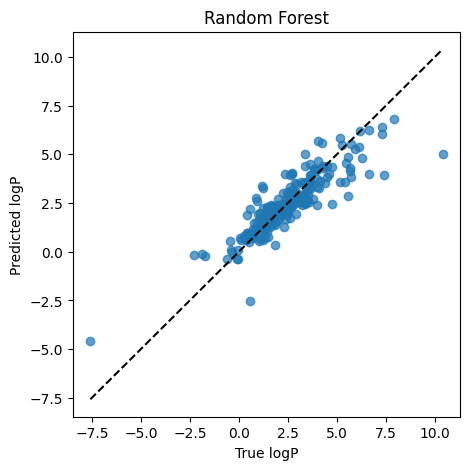

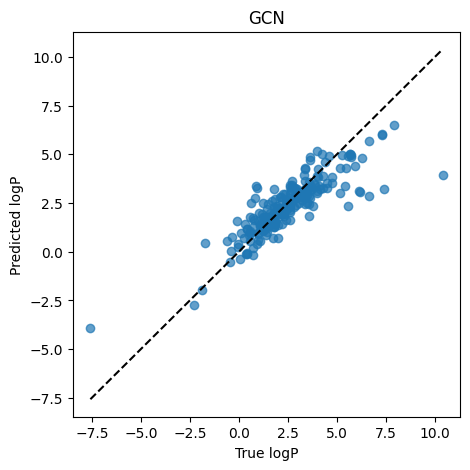

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(y_test, rf_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("True logP")
plt.ylabel("Predicted logP")
plt.title("Random Forest")
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(y_true_gnn, y_pred_gnn, alpha=0.7)
plt.plot([y_true_gnn.min(), y_true_gnn.max()], [y_true_gnn.min(), y_true_gnn.max()], 'k--')
plt.xlabel("True logP")
plt.ylabel("Predicted logP")
plt.title("GCN")
plt.show()

### Discussion points
1) Which model (supervised or unsupervised) performed better on the test set, and why?
2) What did you try to improve model performance of your GNN? What did work, what did not work?
3) Which challenges did you face in the process of building the models?
4) Which of your two models would you recommend to a chemist for predicting logP, and why?

1. RF with morgan worked better accordance to R2 and RMSE value on test set. I think because of small and structured data.

2. Tried to change the number of layers in GCN , adjust hidden dimensions, adjusted dropouts to reduce overfitting, tried to change lr and number of epochs

Depth (improved performance), dropout(stabilizes training) and early stopping (overfitting prevention) worked .

Hidden dimensions didnt worked significantly based on this small dataset.

3. a) Converting SMILES strings into graph representations with meaningful atom features
   b) Avoiding overfitting in the GNN due to limited data

4. for this dataset RF with morgan fingerprint because it Provides better predictive performance, is simpler to implement and train, requires less computational effort, is more robust for small to medium-sized datasets